# Statistics, ML Models, and Evaluation

**Statistics for Data Science**

In [121]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import LabelEncoder,MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import sklearn.model_selection as model_selection

from sklearn.neighbors import KNeighborsRegressor

import sklearn.linear_model as linear_model
import sklearn.metrics as metrics
from sklearn.preprocessing import StandardScaler
from numpy.random import binomial
from numpy.random import poisson
from scipy.stats import ttest_ind

In [122]:
import kagglehub
vikrishnan_boston_house_prices_path = kagglehub.dataset_download('vikrishnan/boston-house-prices')

print('Data source import complete.')

Data source import complete.


In [123]:
path=os.listdir(vikrishnan_boston_house_prices_path)
path

['housing.csv']

In [124]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
data = pd.read_csv(vikrishnan_boston_house_prices_path+'/'+path[0], header=None, delimiter=r"\s+", names=column_names)
data.head(10)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222.0,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311.0,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311.0,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311.0,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311.0,15.2,386.71,17.10,18.9


In [125]:
#Understand mean, median, mode, standard deviation
data=pd.DataFrame(data)
data.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [126]:
data.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [127]:
#mean
df=pd.DataFrame({"Mean_CRIM":[data["CRIM"].mean()]})
df


,Mean_CRIM
0,3.613524


In [128]:
#median
df.insert(loc=1, column="Median_CRIM" , value=data["CRIM"].median())
df

,Mean_CRIM,Median_CRIM
0,3.613524,0.25651


In [129]:
#mode
df.insert(loc=2, column="Mode_CRIM" , value=data["CRIM"].mode())
df

,Mean_CRIM,Median_CRIM,Mode_CRIM
0,3.613524,0.25651,0.01501


In [130]:
# standard deviation
df.insert(loc=3,column="Std_CRIM",value=data["CRIM"].std())
df

,Mean_CRIM,Median_CRIM,Mode_CRIM,Std_CRIM
0,3.613524,0.25651,0.01501,8.601545


Probability Distribution tells about **"Describes how data is spread"**

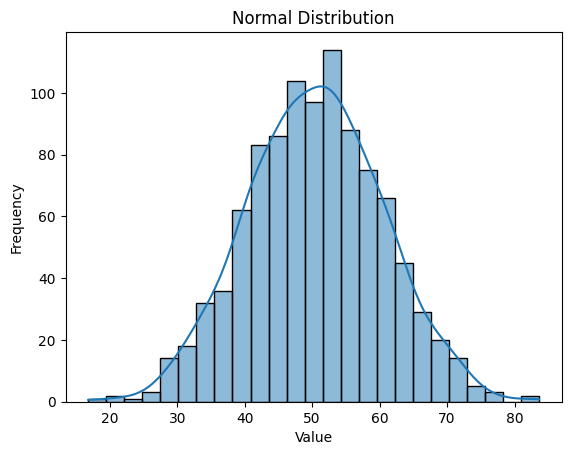

In [131]:
#Learn about probability distributions
#(Normal,Uniform,Binomial,Poisson Distribution)

d = np.random.normal(loc=50, scale=10, size=1000)

# Plot histogram + KDE (smooth curve)  #Guassian distribution
sns.histplot(d, kde=True)
plt.title("Normal Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()


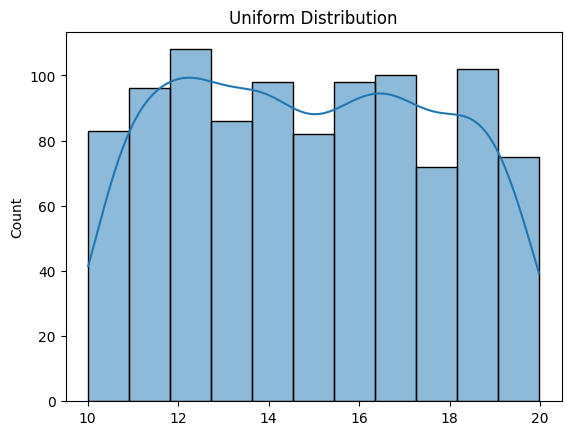

In [132]:
#uniform
d = np.random.uniform(low=10, high=20, size=1000)

sns.histplot(d, kde=True)
plt.title("Uniform Distribution")
plt.show()


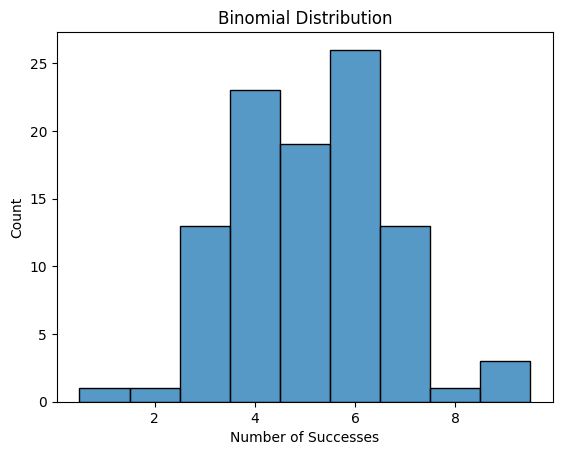

In [133]:
#binomial (Discrete)
# 1000 experiments: 10 coin flips each, 0.5 probability
d = binomial(n=10, p=0.5, size=100)

sns.histplot(d, bins=11, discrete=True)
plt.title("Binomial Distribution")
plt.xlabel("Number of Successes")
plt.show()


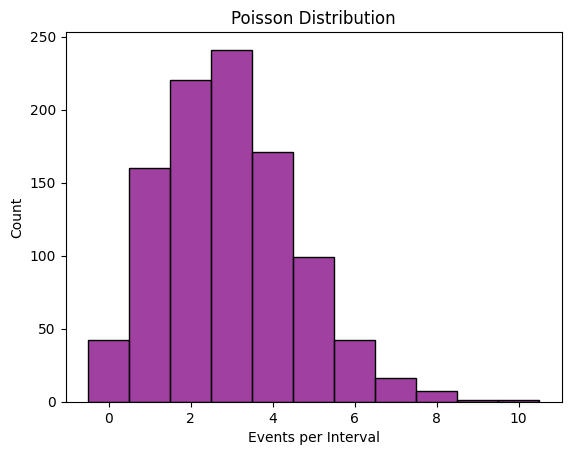

In [134]:
#poisson distribution
d = poisson(lam=3, size=1000)

sns.histplot(d, bins=15, discrete=True , color="purple")
plt.title("Poisson Distribution")
plt.xlabel("Events per Interval")
plt.show()

CLT tells about **"allows us to use normal distribution to make inferences, even when data is not normal"**

Theorm:

If you take many random samples from any population (even if it's not normally distributed), the mean of those samples will be approximately normally distributed

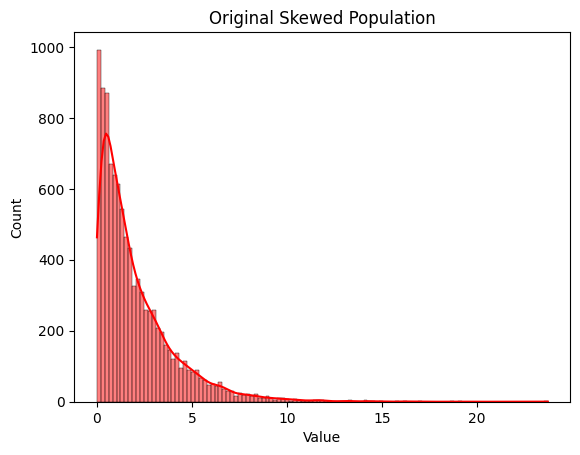

In [135]:
#central Limit Theorem (CLT)


# Skewed data (Exponential distribution) >>> not normal data/population
population = np.random.exponential(scale=2, size=10000)

sns.histplot(population, kde=True, color='red')
plt.title("Original Skewed Population")
plt.xlabel("Value")
plt.show()



In [136]:
#take random sample data and cal sample mean  from population as per above descibe
sample_means = []

# Take 1000 samples, each of size 30
for _ in range(1000):
    sample = np.random.choice(population, size=30)
    sample_means.append(np.mean(sample))



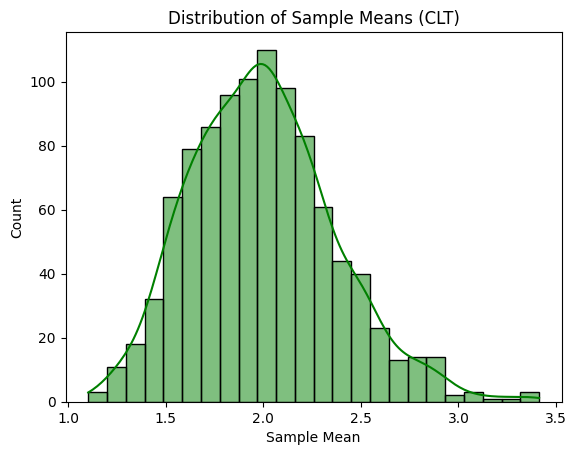

In [137]:
#now plot sample mean
sns.histplot(sample_means, kde=True, color='green')
plt.title("Distribution of Sample Means (CLT)")
plt.xlabel("Sample Mean")
plt.show()


 Perform **hypothesis testing** (t-test, chi-square test).

In [138]:
#t-test  (for comparing means between two variables) >>>
#To compare means (averages) between two groups and see if the difference is statistically significant.
#If p < 0.05, reject H₀

var_high_price = data[data["RM"] >= 6]['MEDV']
var_low_price = data[data["RM"] < 6]['MEDV']


In [139]:
t_stat, p_val = ttest_ind(var_high_price,var_low_price)

print("t-statistic:", t_stat)
print("p-value:", p_val)


#here hypothesis tells , more room leads to more price
#and p-value>0.5 it's prove that above hypothesis is true.

t-statistic: 9.720848939069086
p-value: 1.3808037019840947e-20


In [140]:
#Chi-square Test (To test if there is a relationship between two categorical variables. )
#Test association between variables



# Is Charles River proximity associated with higher prices?
#intially , we start with hypothesis that river and price and independent entity

#generate catergories of high price/low prices to campare with river assocation
df=pd.DataFrame()
df['HighPrice'] = (data['MEDV'] >= data['MEDV'].median()).astype(int)
df




,HighPrice
0,1
1,1
2,1
3,1
4,1
...,...
501,1
502,0
503,1
504,1


In [141]:
contingency = pd.crosstab(data['CHAS'], df['HighPrice']) #crosstab used for categorical variable
print(contingency)

HighPrice    0    1
CHAS               
0          242  229
1            9   26


In [142]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square statistic:", chi2)
print("p-value:", p)


#If p < 0.05, proximity to the Charles River affects house prices.
#also in contingency matrix , we see even though , no river existence(but price is high) and vice vrsa

Chi-square statistic: 7.588871882805446
p-value: 0.005872968898705256


**Introduction to Machine Learning**

In [143]:
X=data.drop("MEDV",axis=1)
Y=data["MEDV"]

train_X, test_X, train_y, test_y = train_test_split(X,Y, test_size=0.2, random_state=42)
print("Training set size:", train_X.shape)
print("Test set size:", test_X.shape)
print("Train, Number of features:", train_y.shape)
print('test, Number of feature', test_y.shape)

Training set size: (404, 13)
Test set size: (102, 13)
Train, Number of features: (404,)
test, Number of feature (102,)


In [144]:
#linear regression, k-nearest neighbors
model=linear_model.LinearRegression()
model.fit(train_X,train_y)

LinearRegression()

In [145]:
predict_y=model.predict(test_X)

Let's calculate some regression metrics to evaluate the linear regression model.

In [146]:
# Calculate regression metrics
mae_reg = mean_absolute_error(test_y, predict_y)
mse_reg = mean_squared_error(test_y, predict_y)
rmse_reg = np.sqrt(mse_reg)
r2_reg = r2_score(test_y, predict_y)
acc_reg=model.score(test_X,test_y)


print(f"Mean Absolute Error (MAE)-Regression: {mae_reg:.2f}")
print(f"Mean Squared Error (MSE)-Regression: {mse_reg:.2f}")
print(f"Root Mean Squared Error (RMSE)-Regression: {rmse_reg:.2f}")
print(f"R-squared (R2)-Regression: {r2_reg:.2f}")
print(f"Accuracy-Regression: {acc_reg:.2f}")


Mean Absolute Error (MAE)-Regression: 3.19
Mean Squared Error (MSE)-Regression: 24.29
Root Mean Squared Error (RMSE)-Regression: 4.93
R-squared (R2)-Regression: 0.67
Accuracy-Regression: 0.67


In [147]:
#k-nn

# Create a KNN regressor
knn = KNeighborsRegressor(n_neighbors=3)

# Train the model
knn.fit(train_X, train_y)
predict_y_knn = knn.predict(test_X)

In [148]:
# Calculate regression metrics
mae_reg_knn = mean_absolute_error(test_y, predict_y_knn)
mse_reg_knn = mean_squared_error(test_y, predict_y_knn)
rmse_reg_knn = np.sqrt(mse_reg)
r2_reg_knn = r2_score(test_y, predict_y_knn)
acc_reg_knn=model.score(test_X,test_y)


print(f"Mean Absolute Error (MAE)-Regression: {mae_reg_knn:.2f}")
print(f"Mean Squared Error (MSE)-Regression: {mse_reg_knn:.2f}")
print(f"Root Mean Squared Error (RMSE)-Regression: {rmse_reg_knn:.2f}")
print(f"R-squared (R2)-Regression: {r2_reg_knn:.2f}")
print(f"Accuracy-Regression: {acc_reg_knn:.2f}")



Mean Absolute Error (MAE)-Regression: 3.34
Mean Squared Error (MSE)-Regression: 21.66
Root Mean Squared Error (RMSE)-Regression: 4.93
R-squared (R2)-Regression: 0.70
Accuracy-Regression: 0.67


In [149]:
#plot confusion matrix - for classification problem  (housing problem output is discreate values)

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score

X, y = make_classification(
    n_samples=1000,    # 1000 samples
    n_features=10,     # 10 features
    n_informative=5,   # 5 features actually affect output
    n_redundant=2,     # 2 redundant features
    n_classes=2,       # Binary classification
    random_state=42
)

# Spliting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


In [150]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


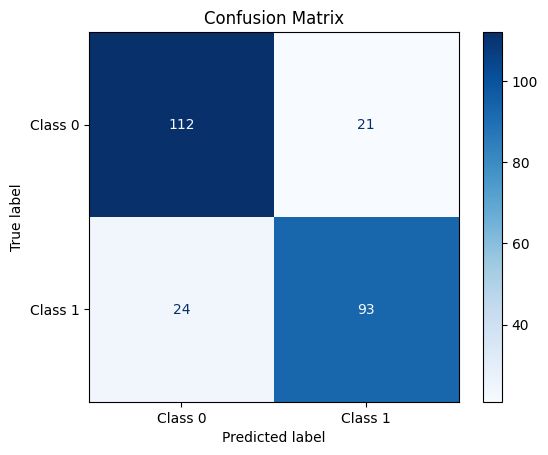

In [151]:

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()


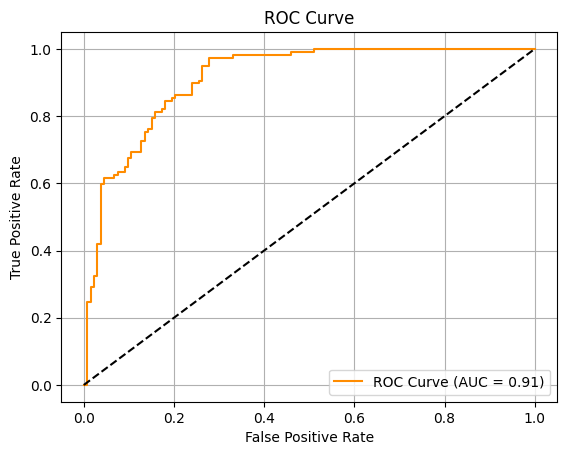

In [152]:

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--')  # random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()
